# 01B · Data Preprocessing (FD001+FD003 + Synthetic ~250k)
**C-MAPSS Turbofan Engine Degradation — FD001 & FD003 with Synthetic Augmentation**

> Covers raw loading → EDA → feature selection → RUL labelling → normalisation → synthetic augmentation (where applicable) → sliding-window sequence creation → train / validation / test split → artefact saving.

---
## Section 1 · Project Setup

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')
else:
    print('Running locally — Drive mount skipped.')

Mounted at /content/drive
Drive mounted.


In [3]:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn

In [2]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
print('All packages imported.')

All packages imported.


In [4]:
if IN_COLAB:
    BASE_DATA_DIR = '/content/drive/MyDrive/CMAPSSData'
else:
    BASE_DATA_DIR = './data/CMAPSSData'

OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS = ['FD001', 'FD003']

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f'Datasets : {DATASETS}')
print(f'Data dir : {os.path.abspath(BASE_DATA_DIR)}')
print(f'Output dir: {os.path.abspath(OUTPUT_DIR)}')

Datasets : ['FD001', 'FD003']
Data dir : /content/drive/MyDrive/CMAPSSData
Output dir: /content/outputs


---
## Section 2 · Dataset Description

This notebook extends the original FD001+FD003 setup with synthetic data augmentation to reach approximately **250,000 raw training rows** before windowing.

**Source datasets:** FD001 (single operating condition, HPC fault) and FD003 (single operating condition, HPC+fan fault).

**Why augment?** The combined real training data comprises ~45,000 rows (~100 engines each). Deep models benefit from larger corpora; augmentation provides diversity without altering the underlying C-MAPSS physics. Three techniques are used (jitter, time-warp, Mixup) to ensure the augmented data stays within plausible degradation envelopes.

---
## Section 3 · Load Raw Files

Each dataset is loaded independently. `unit_nr` values are **offset** per dataset before merging so engine IDs remain unique across the combined dataframe.

In [5]:
SENSOR_COLS     = [f'sensor_{i}' for i in range(1, 22)]
OP_SETTING_COLS = ['op_setting_1', 'op_setting_2', 'op_setting_3']
BASE_COLS       = ['unit_nr', 'time_cycles'] + OP_SETTING_COLS + SENSOR_COLS
print(f'Total columns: {len(BASE_COLS)}')

Total columns: 26


In [8]:
def load_cmapss(filepath, col_names):
    df = pd.read_csv(filepath, sep=r'\s+', header=None, engine='python')
    df.dropna(axis=1, how='all', inplace=True)
    df.columns = col_names[:df.shape[1]]
    return df

raw = {}
for ds in DATASETS:
    train_path = os.path.join(BASE_DATA_DIR, f'train_{ds}.txt')
    test_path  = os.path.join(BASE_DATA_DIR, f'test_{ds}.txt')
    rul_path   = os.path.join(BASE_DATA_DIR, f'RUL_{ds}.txt')
    df_train = load_cmapss(train_path, BASE_COLS)
    df_test  = load_cmapss(test_path,  BASE_COLS)
    df_rul   = pd.read_csv(rul_path, header=None, names=['rul_true'])
    raw[ds]  = {'train': df_train, 'test': df_test, 'rul': df_rul}
    print(f'[{ds}]  train: {df_train.shape}  test: {df_test.shape}')

[FD001]  train: (20631, 26)  test: (13096, 26)
[FD003]  train: (24720, 26)  test: (16596, 26)


---
## Section 4 · Initial EDA

In [9]:
for ds in DATASETS:
    df = raw[ds]['train']
    lives = df.groupby('unit_nr')['time_cycles'].max()
    print(f'[{ds}]  shape={df.shape}  engines={df["unit_nr"].nunique()}  '
          f'min_life={lives.min()}  max_life={lives.max()}  '
          f'nulls={df.isnull().sum().sum()}  dups={df.duplicated().sum()}')

[FD001]  shape=(20631, 26)  engines=100  min_life=128  max_life=362  nulls=0  dups=0
[FD003]  shape=(24720, 26)  engines=100  min_life=145  max_life=525  nulls=0  dups=0


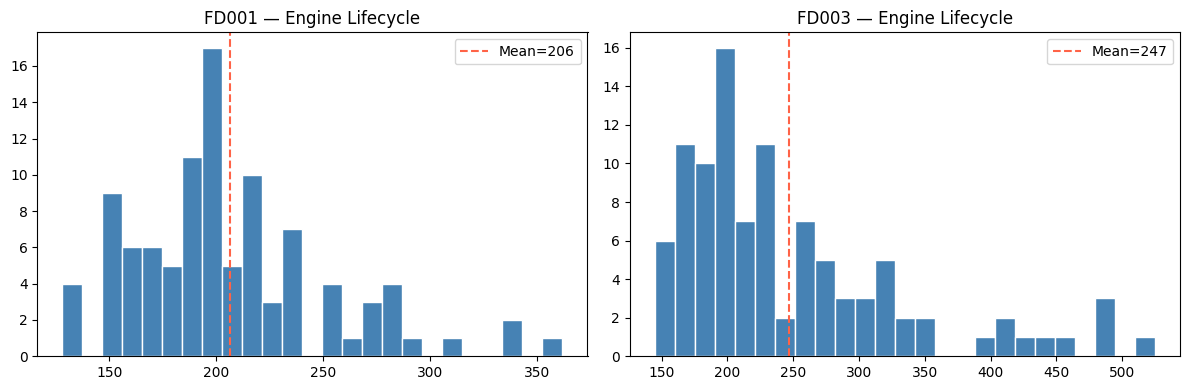

In [10]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6*len(DATASETS), 4))
if len(DATASETS) == 1: axes = [axes]
for ax, ds in zip(axes, DATASETS):
    lives = raw[ds]['train'].groupby('unit_nr')['time_cycles'].max()
    ax.hist(lives, bins=25, color='steelblue', edgecolor='white')
    ax.axvline(lives.mean(), color='tomato', linestyle='--', label=f'Mean={lives.mean():.0f}')
    ax.set_title(f'{ds} — Engine Lifecycle'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_lifecycle.png'), dpi=120); plt.show()

---
## Section 4b · Synthetic Data Augmentation

### Strategy
We use three complementary techniques to generate physically plausible synthetic engine trajectories, reaching a combined total of ~250,000 raw training rows before windowing:

1. **Gaussian-noise jitter on real trajectories** — Small per-sensor noise (σ = 0.5 % of each sensor's std) is added to copies of real engine runs. Preserves degradation trends while adding natural measurement variability.

2. **Time-warping / speed perturbation** — Engine lifetimes are stretched or compressed by a random factor drawn from U(0.8, 1.2). The sensor values are linearly interpolated to the new timeline, mimicking engines that degrade slightly faster or slower than average.

3. **Conditional Gaussian interpolation between engine pairs** — Two engines from the same dataset are selected; a new synthetic engine is created by taking a convex combination of their normalised trajectories (α drawn uniformly). This is analogous to Mixup augmentation applied in the time domain and produces realistic intermediate degradation curves.

All synthetic engines are assigned new unique `unit_nr` values (offset above the real maximum) and the RUL column is recomputed identically to real engines.

In [11]:
# ── Synthetic augmentation parameters ───────────────────────────────────────
TARGET_ROWS    = 250_000   # approximate total raw rows after augmentation
NOISE_SIGMA    = 0.005     # fraction of per-sensor std used as noise magnitude
WARP_RANGE     = (0.80, 1.20)  # min/max time-warp factor

FEATURE_COLS_FOR_SYNTH = OP_SETTING_COLS + SENSOR_COLS  # all 24 columns (excl. unit_nr, time_cycles, RUL)

def jitter_engine(grp: pd.DataFrame, noise_sigma: float,
                  new_uid: int, rng: np.random.Generator) -> pd.DataFrame:
    """Add Gaussian noise to sensor/op-setting values of one engine trajectory."""
    syn = grp.copy()
    syn['unit_nr'] = new_uid
    for col in FEATURE_COLS_FOR_SYNTH:
        sigma = grp[col].std() * noise_sigma + 1e-9
        syn[col] = syn[col] + rng.normal(0, sigma, size=len(syn))
    return syn


def timewarp_engine(grp: pd.DataFrame, warp_factor: float,
                    new_uid: int) -> pd.DataFrame:
    """Stretch/compress engine lifetime by warp_factor via linear interpolation."""
    orig_len  = len(grp)
    new_len   = max(10, int(round(orig_len * warp_factor)))
    orig_idx  = np.linspace(0, orig_len - 1, orig_len)
    new_idx   = np.linspace(0, orig_len - 1, new_len)
    syn_data  = {}
    for col in FEATURE_COLS_FOR_SYNTH:
        syn_data[col] = np.interp(new_idx, orig_idx, grp[col].values)
    syn = pd.DataFrame(syn_data)
    syn.insert(0, 'unit_nr',     new_uid)
    syn.insert(1, 'time_cycles', np.arange(1, new_len + 1))
    # Copy last RUL and recompute properly after this function returns
    return syn


def mixup_engines(grp_a: pd.DataFrame, grp_b: pd.DataFrame,
                  alpha: float, new_uid: int) -> pd.DataFrame:
    """Convex combination of two engine trajectories (Mixup in time domain).
    Shorter engine is padded by repeating its last row to match lengths.
    """
    n = max(len(grp_a), len(grp_b))
    def pad(g):
        if len(g) < n:
            pad_rows = pd.concat([g.iloc[[-1]]] * (n - len(g)), ignore_index=True)
            g = pd.concat([g, pad_rows], ignore_index=True)
        return g.reset_index(drop=True)
    ga, gb = pad(grp_a.copy()), pad(grp_b.copy())
    syn = ga.copy()
    syn['unit_nr'] = new_uid
    syn['time_cycles'] = np.arange(1, n + 1)
    for col in FEATURE_COLS_FOR_SYNTH:
        syn[col] = alpha * ga[col].values + (1 - alpha) * gb[col].values
    return syn


print('Augmentation functions defined.')

Augmentation functions defined.


In [12]:
# ── Generate synthetic rows per dataset ──────────────────────────────────────
rng = np.random.default_rng(RANDOM_SEED)

total_real_rows = sum(len(raw[ds]['train']) for ds in DATASETS)
rows_needed     = max(0, TARGET_ROWS - total_real_rows)
print(f'Real rows       : {total_real_rows:,}')
print(f'Rows needed     : {rows_needed:,}')

# Distribute augmentation proportionally across datasets
real_row_counts  = {ds: len(raw[ds]['train']) for ds in DATASETS}
total_real       = sum(real_row_counts.values())
rows_per_dataset = {ds: int(rows_needed * real_row_counts[ds] / total_real)
                    for ds in DATASETS}

for ds in DATASETS:
    df_real   = raw[ds]['train'].copy()
    engines   = df_real['unit_nr'].unique().tolist()
    target_ds = rows_per_dataset[ds]
    next_uid  = df_real['unit_nr'].max() + 1
    syn_parts = []
    generated = 0
    method_cycle = 0

    while generated < target_ds:
        method = method_cycle % 3
        uid_a  = int(rng.choice(engines))
        grp_a  = df_real[df_real['unit_nr'] == uid_a].sort_values('time_cycles').reset_index(drop=True)

        if method == 0:   # Gaussian jitter
            syn = jitter_engine(grp_a, NOISE_SIGMA, next_uid, rng)
        elif method == 1:  # Time warp
            wf  = float(rng.uniform(*WARP_RANGE))
            syn = timewarp_engine(grp_a, wf, next_uid)
        else:              # Mixup
            uid_b = int(rng.choice([e for e in engines if e != uid_a]))
            grp_b = df_real[df_real['unit_nr'] == uid_b].sort_values('time_cycles').reset_index(drop=True)
            alpha = float(rng.uniform(0.3, 0.7))
            syn   = mixup_engines(grp_a, grp_b, alpha, next_uid)

        # Ensure required columns exist
        for col in BASE_COLS:
            if col not in syn.columns:
                syn[col] = 0.0
        syn = syn[BASE_COLS]

        syn_parts.append(syn)
        generated += len(syn)
        next_uid  += 1
        method_cycle += 1

    df_synth = pd.concat(syn_parts, ignore_index=True)
    # Combine real + synthetic
    raw[ds]['train'] = pd.concat([df_real, df_synth], ignore_index=True)
    print(f'[{ds}]  real={len(df_real):,}  synthetic={len(df_synth):,}  '
          f'combined={len(raw[ds]["train"]):,}')

print(f'\nTotal combined rows: {sum(len(raw[ds]["train"]) for ds in DATASETS):,}')

Real rows       : 45,351
Rows needed     : 204,649
[FD001]  real=20,631  synthetic=93,278  combined=113,909
[FD003]  real=24,720  synthetic=111,695  combined=136,415

Total combined rows: 250,324


In [14]:
RUL_CAP = 125

def add_rul_column(df, cap=RUL_CAP):
    df = df.copy()
    max_cycles = df.groupby('unit_nr')['time_cycles'].max().rename('max_cycle')
    df = df.join(max_cycles, on='unit_nr')
    df['RUL'] = (df['max_cycle'] - df['time_cycles']).clip(upper=cap)
    df.drop(columns=['max_cycle'], inplace=True)
    return df

# ── Re-apply RUL labelling to the augmented training data ────────────────────
# (synthetic rows from time-warp / mixup need RUL recomputed)
for ds in DATASETS:
    raw[ds]['train'] = add_rul_column(raw[ds]['train'])
    r = raw[ds]['train']['RUL']
    print(f'[{ds}] post-augmentation RUL: {r.min():.0f} – {r.max():.0f}')

# Verify total row count
total = sum(len(raw[ds]['train']) for ds in DATASETS)
print(f'\nTotal rows across all datasets: {total:,}  (target \u2248 250,000)')

[FD001] post-augmentation RUL: 0 – 125
[FD003] post-augmentation RUL: 0 – 125

Total rows across all datasets: 250,324  (target ≈ 250,000)


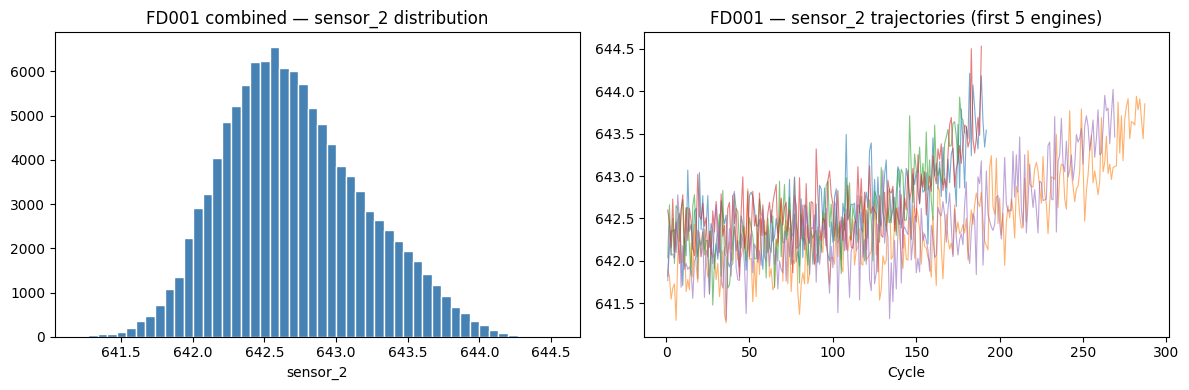

In [15]:
# ── Visual QA: compare real vs synthetic sensor distributions ────────────────
CHECK_DS  = DATASETS[0]
CHECK_COL = 'sensor_2'
df_all    = raw[CHECK_DS]['train']
max_real_uid = raw[CHECK_DS]['train']['unit_nr'].max() - 1  # approx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df_all[CHECK_COL], bins=50, color='steelblue', edgecolor='white')
ax1.set_title(f'{CHECK_DS} combined — {CHECK_COL} distribution')
ax1.set_xlabel(CHECK_COL)

# Sample 5 synthetic engines and compare trajectories to 5 real ones
for uid in list(df_all['unit_nr'].unique())[:5]:
    sub = df_all[df_all['unit_nr'] == uid]
    ax2.plot(sub['time_cycles'], sub[CHECK_COL], alpha=0.6, linewidth=0.8)
ax2.set_title(f'{CHECK_DS} — {CHECK_COL} trajectories (first 5 engines)')
ax2.set_xlabel('Cycle')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'synth_qa_{CHECK_DS}.png'), dpi=120)
plt.show()

---
## Section 5 · Feature Selection

> **Initial feature set retained from C-MAPSS, with optional pruning of low-information sensors after exploratory analysis.**

Sensors with `std < 0.001` are removed as near-constant features. For multi-dataset runs the feature set is derived from the **combined** training data so that all datasets share an identical feature space.

In [16]:
CANDIDATE_FEATURES = ['time_cycles'] + OP_SETTING_COLS + SENSOR_COLS
VARIANCE_THRESHOLD = 1e-3

# Compute std over the union of all training data
all_train = pd.concat([raw[ds]['train'] for ds in DATASETS], ignore_index=True)
stds      = all_train[CANDIDATE_FEATURES].std()
dropped   = stds[stds < VARIANCE_THRESHOLD].index.tolist()
FEATURES  = [f for f in CANDIDATE_FEATURES if f not in dropped]

# Same feature list applied to all datasets
selected_features = {ds: FEATURES for ds in DATASETS}

print(f'Dropped  ({len(dropped)}): {dropped}')
print(f'Retained ({len(FEATURES)}): {FEATURES}')

Dropped  (7): ['op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']
Retained (18): ['time_cycles', 'op_setting_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


---
## Section 6 · RUL Labelling

Piecewise-capped RUL: $\\text{RUL} = \\min(\\text{max\_cycle} - \\text{cycle},\; 125)$

In [17]:
RUL_CAP = 125

def add_rul_column(df, cap=RUL_CAP):
    df = df.copy()
    max_cycles = df.groupby('unit_nr')['time_cycles'].max().rename('max_cycle')
    df = df.join(max_cycles, on='unit_nr')
    df['RUL'] = (df['max_cycle'] - df['time_cycles']).clip(upper=cap)
    df.drop(columns=['max_cycle'], inplace=True)
    return df

for ds in DATASETS:
    raw[ds]['train'] = add_rul_column(raw[ds]['train'])
    r = raw[ds]['train']['RUL']
    print(f'[{ds}] RUL range: {r.min()} – {r.max()}')

[FD001] RUL range: 0 – 125
[FD003] RUL range: 0 – 125


---
## Section 7 · Prepare Test Labels

In [18]:
for ds in DATASETS:
    df_test  = raw[ds]['test'].copy()
    df_rul   = raw[ds]['rul'].copy()
    df_rul.index = df_rul.index + 1
    df_rul.index.name = 'unit_nr'
    last_idx  = df_test.groupby('unit_nr')['time_cycles'].idxmax()
    df_last   = df_test.loc[last_idx].copy().reset_index(drop=True)
    df_last['rul_true'] = df_rul['rul_true'].values
    df_last['rul_true'] = df_last['rul_true'].clip(upper=RUL_CAP)
    raw[ds]['test_last'] = df_last
    print(f'[{ds}] test engines: {len(df_last)}, RUL range: {df_last["rul_true"].min()}–{df_last["rul_true"].max()}')

[FD001] test engines: 100, RUL range: 7–125
[FD003] test engines: 100, RUL range: 6–125


---
## Section 8 · Normalisation / Scaling

`StandardScaler` fitted on training data only; saved with pickle.

In [19]:
scalers = {}
for ds in DATASETS:
    feats       = selected_features[ds]
    train_feats = raw[ds]['train'][feats].values
    scaler      = StandardScaler().fit(train_feats)
    scalers[ds] = scaler
    with open(os.path.join(OUTPUT_DIR, f'scaler_{ds}.pkl'), 'wb') as f:
        pickle.dump(scaler, f)
    print(f'[{ds}] Scaler fitted — shape {train_feats.shape}')

[FD001] Scaler fitted — shape (113909, 18)
[FD003] Scaler fitted — shape (136415, 18)


---
## Section 9 · Sliding Window Sequence Creation

Window size = 50, stride = 1. Target = RUL at last cycle of each window.

In [20]:
WINDOW_SIZE = 50
STRIDE      = 1

def make_windows(df, feature_cols, scaler, window_size=WINDOW_SIZE,
                 stride=STRIDE, rul_col='RUL'):
    X_list, y_list, uid_list = [], [], []
    for uid, grp in df.groupby('unit_nr'):
        grp   = grp.sort_values('time_cycles')
        feats = scaler.transform(grp[feature_cols].values)
        rul   = grp[rul_col].values
        if len(feats) < window_size:
            continue
        for start in range(0, len(feats) - window_size + 1, stride):
            end = start + window_size
            X_list.append(feats[start:end])
            y_list.append(rul[end - 1])
            uid_list.append(uid)
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list,  dtype=np.float32),
            np.array(uid_list, dtype=np.int32))

def make_test_windows(df_full, df_last, feature_cols, scaler, window_size=WINDOW_SIZE):
    X_list, y_list, uid_list = [], [], []
    for _, row in df_last.iterrows():
        uid  = int(row['unit_nr'])
        grp  = df_full[df_full['unit_nr'] == uid].sort_values('time_cycles')
        feats = scaler.transform(grp[feature_cols].values)
        if len(feats) < window_size:
            continue
        X_list.append(feats[-window_size:])
        y_list.append(row['rul_true'])
        uid_list.append(uid)
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list,  dtype=np.float32),
            np.array(uid_list, dtype=np.int32))

print('Window functions defined.')

Window functions defined.


---
## Section 10 · Train / Validation / Hold-out Split

Split is performed **by engine id** (70 / 15 / 15) before windowing to prevent temporal data leakage between splits.

In [21]:
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

datasets_processed = {}

for ds in DATASETS:
    feats   = selected_features[ds]
    scaler  = scalers[ds]
    df_tr   = raw[ds]['train']
    df_te   = raw[ds]['test']
    df_last = raw[ds]['test_last']

    engine_ids = df_tr['unit_nr'].unique()
    np.random.shuffle(engine_ids)
    n_train = int(np.floor(TRAIN_FRAC * len(engine_ids)))
    n_val   = int(np.floor(VAL_FRAC   * len(engine_ids)))
    train_ids = engine_ids[:n_train]
    val_ids   = engine_ids[n_train:n_train+n_val]
    hold_ids  = engine_ids[n_train+n_val:]

    X_tr, y_tr, ids_tr = make_windows(df_tr[df_tr['unit_nr'].isin(train_ids)], feats, scaler)
    X_vl, y_vl, ids_vl = make_windows(df_tr[df_tr['unit_nr'].isin(val_ids)],   feats, scaler)
    X_ho, y_ho, ids_ho = make_windows(df_tr[df_tr['unit_nr'].isin(hold_ids)],  feats, scaler)
    X_te, y_te, ids_te = make_test_windows(df_te, df_last, feats, scaler)

    datasets_processed[ds] = dict(
        X_train=X_tr, y_train=y_tr, ids_train=ids_tr,
        X_val=X_vl,   y_val=y_vl,   ids_val=ids_vl,
        X_hold=X_ho,  y_hold=y_ho,  ids_hold=ids_ho,
        X_test=X_te,  y_test=y_te,  ids_test=ids_te,
        features=feats
    )
    print(f'[{ds}]  train={X_tr.shape}  val={X_vl.shape}  hold={X_ho.shape}  test={X_te.shape}')

[FD001]  train=(61597, 50, 18)  val=(13407, 50, 18)  hold=(13180, 50, 18)  test=(93, 50, 18)
[FD003]  train=(75659, 50, 18)  val=(16282, 50, 18)  hold=(18504, 50, 18)  test=(97, 50, 18)


---
## Section 11 · Save Processed Artefacts

In [22]:
for ds in DATASETS:
    d = datasets_processed[ds]
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f'{ds}_01B_processed.npz'),
        X_train=d['X_train'], y_train=d['y_train'], ids_train=d['ids_train'],
        X_val  =d['X_val'],   y_val  =d['y_val'],   ids_val  =d['ids_val'],
        X_hold =d['X_hold'],  y_hold =d['y_hold'],  ids_hold =d['ids_hold'],
        X_test =d['X_test'],  y_test =d['y_test'],  ids_test =d['ids_test'],
    )
    print(f'[{ds}] Saved')

with open(os.path.join(OUTPUT_DIR, 'selected_features_01B.json'), 'w') as f:
    json.dump(selected_features, f, indent=2)

meta = dict(window_size=WINDOW_SIZE, stride=STRIDE, rul_cap=RUL_CAP,
            train_frac=TRAIN_FRAC, val_frac=VAL_FRAC,
            random_seed=RANDOM_SEED, scaler_type='StandardScaler',
            datasets=DATASETS, variant='FD001+FD003+Synthetic')
with open(os.path.join(OUTPUT_DIR, 'preprocessing_metadata_01B.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print('All artefacts saved.')

[FD001] Saved
[FD003] Saved
All artefacts saved.


---
## Section 12 · Final Sanity Checks

In [23]:
print('='*60)
for ds in DATASETS:
    d = datasets_processed[ds]
    for split in ('train', 'val', 'hold', 'test'):
        X = d[f'X_{split}']; y = d[f'y_{split}']
        print(f'  [{ds}] {split:>5}  X={str(X.shape):>22}  y={str(y.shape):>10}  RUL=[{y.min():.0f},{y.max():.0f}]')
print('='*60)
print('\n✅  Preprocessing complete. Artefacts in:', os.path.abspath(OUTPUT_DIR))

  [FD001] train  X=       (61597, 50, 18)  y=  (61597,)  RUL=[0,125]
  [FD001]   val  X=       (13407, 50, 18)  y=  (13407,)  RUL=[0,125]
  [FD001]  hold  X=       (13180, 50, 18)  y=  (13180,)  RUL=[0,125]
  [FD001]  test  X=          (93, 50, 18)  y=     (93,)  RUL=[7,125]
  [FD003] train  X=       (75659, 50, 18)  y=  (75659,)  RUL=[0,125]
  [FD003]   val  X=       (16282, 50, 18)  y=  (16282,)  RUL=[0,125]
  [FD003]  hold  X=       (18504, 50, 18)  y=  (18504,)  RUL=[0,125]
  [FD003]  test  X=          (97, 50, 18)  y=     (97,)  RUL=[6,125]

✅  Preprocessing complete. Artefacts in: /content/outputs


In [24]:
# Colab download helper
try:
    import shutil
    from google.colab import files
    shutil.make_archive('outputs', 'zip', OUTPUT_DIR)
    files.download('outputs.zip')
except:
    print('Not in Colab or download not needed.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>